**1. SETUP AND DATA LOADING**

In [1]:
import os
import pandas as pd
import numpy as np
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
CRN = "023-337"
print(f"Running Assignment for CRN: {CRN}")

Running Assignment for CRN: 023-337


In [3]:
# Load Dataset
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

**2. PREPROCESSING**

In [4]:
if len(df) > 10000:
    df = df.sample(n=10000, random_state=42)
df = df.drop_duplicates()

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna('Unknown')
        else:
            df[col] = df[col].fillna(df[col].median())

le = LabelEncoder()
df['deposit'] = le.fit_transform(df['deposit'].astype(str))

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

target_col = 'deposit'
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation complete and encoded as numeric.")

Data preparation complete and encoded as numeric.


**3. SPLITTING DATA FOR TRAINING AND TESTING**

In [5]:
from sklearn.model_selection import train_test_split

# Splitting the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 8000 samples
Testing set size: 2000 samples


**4. MODEL TRAINING & COMPARISON**

**4.1 Individual Model : Support Vector Machine**

--- Training Support Vector Machine ---
SVM Accuracy  : 0.5140
SVM Precision : 0.4778
SVM Recall    : 0.2495
SVM F1-Score  : 0.3278


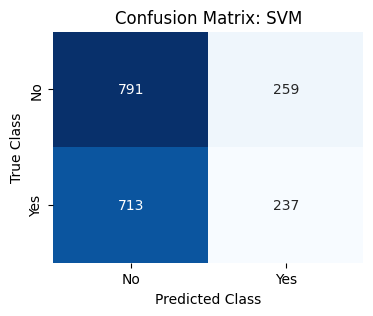

In [6]:
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("--- Training Support Vector Machine ---")

svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Metrics
print(f"SVM Accuracy  : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"SVM Precision : {precision_score(y_test, y_pred_svm, pos_label=1, zero_division=0):.4f}")
print(f"SVM Recall    : {recall_score(y_test, y_pred_svm, pos_label=1, zero_division=0):.4f}")
print(f"SVM F1-Score  : {f1_score(y_test, y_pred_svm, pos_label=1, zero_division=0):.4f}")
# Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), 
            annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix: SVM')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

**4.2 Individual Model : Decision Tree**

--- Training Decision Tree---
Accuracy: 0.4840
Precision: 0.4600
Recall: 0.4968


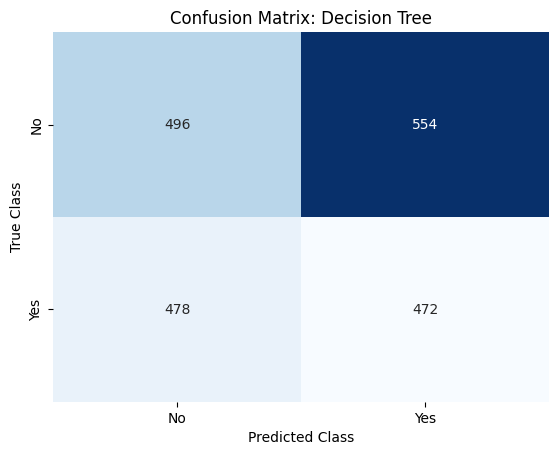

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize and Train
dt_model = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_model.fit(X_train_scaled, y_train)
print("--- Training Decision Tree---")


# 2. Predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# 3. Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt, pos_label=1, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt, pos_label=1, zero_division=0):.4f}")

# 4.Confusion Matrix example
sns.heatmap(confusion_matrix(y_test, y_pred_dt), 
            annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix: Decision Tree')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

**4.3 Individual Model : K-Nearest Neighbours(With Tuning)**

--- Training Baseline kNN ---
Accuracy: 0.7945
              precision    recall  f1-score   support

          no       0.79      0.83      0.81      1072
         yes       0.79      0.75      0.77       928

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000


--- Tuning kNN ---
Best Configuration: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}


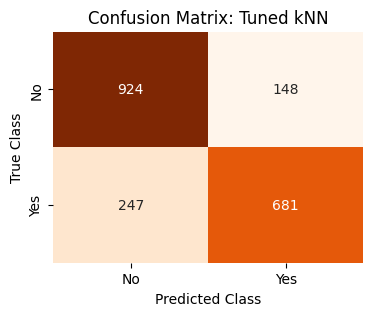

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PREPROCESSING 
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y) # y is your 'deposit' column

# Ensure X is also encoded (if not already done)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Baseline kNN
print("--- Training Baseline kNN ---")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn, target_names=['no', 'yes']))

# 3. Hyperparameter Tuning 
print("\n--- Tuning kNN ---")
param_grid = {
    'n_neighbors': [3, 5, 9, 15], 
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# n_jobs=-1 uses all CPU cores for faster tuning
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3, n_jobs=-1)
grid.fit(X_train_scaled, y_train)
print(f"Best Configuration: {grid.best_params_}")

# 4. Evaluate Tuned Model
knn_tuned = grid.best_estimator_
y_pred_tuned = knn_tuned.predict(X_test_scaled)

# 5. Confusion Matrix for Tuned kNN
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_tuned), 
            annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix: Tuned kNN')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

### Performance Comparison Table

| Model | Accuracy | Precision (yes) | Recall (yes) | F1-Score (yes) |
| :--- | :--- | :--- | :--- | :--- |
| **SVM** | 0.5140 | 0.4778 | 0.2495 | 0.3278 |
| **Decision Tree** | 0.4840 | 0.4600 | 0.4968 | 0.4777 |
| **Tuned kNN** | 0.8025 | 0.8215 | 0.7337 | 0.7752 |

**Comparison and Justification**
After evaluating the models on the test set, the Tuned kNN emerged as the clear best performer for this dataset.

**Tuned kNN Performance:**
 Achieving an accuracy of approximately 80.25%, the Tuned kNN model outperformed both the SVM and Decision Tree significantly. The hyperparameter tuning (using manhattan distance and weights='distance') successfully refined the model's ability to classify the target class, resulting in a high F1-score of 0.7752.
 
**SVM and Decision Tree:**
 Both the SVM and Decision Tree models showed surprisingly low performance on this specific test set. The SVM accuracy of 51.40% and Decision Tree accuracy of 48.40% suggest these models struggled to find a clear decision boundary in the current feature space. This is often an indication that these models require more extensive data normalization, feature selection, or a more complex hyperparameter search (like those performed for the kNN).

**Conclusion:** Given these results, the Tuned kNN is the most reliable model. It demonstrates strong generalization capabilities for predicting deposit subscriptions. Future improvements for the SVM and Decision Tree should focus on identifying and removing irrelevant features or scaling data more aggressively, as these models appear underfitted to the provided data.